# Grounded SAM 2 — Octopus Segmentation
Uses Grounding DINO to detect the octopus by text prompt, then SAM 2 to produce a precise mask.

In [18]:
# Install dependencies (run once)
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# !pip install git+https://github.com/facebookresearch/sam2.git
# !pip install git+https://github.com/IDEA-Research/GroundingDINO.git
# !pip install supervision opencv-python matplotlib Pillow

In [19]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Download model weights

In [20]:
import urllib.request

WEIGHTS_DIR = Path("weights")
WEIGHTS_DIR.mkdir(exist_ok=True)

SAM2_CHECKPOINT = WEIGHTS_DIR / "sam2_hiera_large.pt"
GDINO_CHECKPOINT = WEIGHTS_DIR / "groundingdino_swint_ogc.pth"
GDINO_CONFIG = "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"

if not SAM2_CHECKPOINT.exists():
    print("Downloading SAM 2 weights...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt",
        SAM2_CHECKPOINT
    )
    print("Done.")

if not GDINO_CHECKPOINT.exists():
    print("Downloading Grounding DINO weights...")
    urllib.request.urlretrieve(
        "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth",
        GDINO_CHECKPOINT
    )
    print("Done.")

## 2. Load models

In [21]:
# --- Grounding DINO ---
from groundingdino.util.inference import load_model as load_gdino, predict as gdino_predict
from groundingdino.util import box_ops

gdino_model = load_gdino(GDINO_CONFIG, str(GDINO_CHECKPOINT))
gdino_model = gdino_model.to(DEVICE)
print("Grounding DINO loaded.")

final text_encoder_type: bert-base-uncased
Grounding DINO loaded.


In [22]:
# --- SAM 2 ---
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_model = build_sam2("configs/sam2/sam2_hiera_l", str(SAM2_CHECKPOINT), device=DEVICE)
sam2_predictor = SAM2ImagePredictor(sam2_model)
print("SAM 2 loaded.")

SAM 2 loaded.


## 3. Helper functions

In [23]:
import groundingdino.datasets.transforms as GDT
from PIL import ImageDraw, ImageFont

COLORS     = [(255, 80, 80), (80, 255, 80), (80, 80, 255), (255, 200, 0)]
COLORS_MPL = ["#FF5050",    "#50FF50",     "#5050FF",     "#FFC800"   ]

GDINO_TRANSFORM = GDT.Compose([
    GDT.RandomResize([800], max_size=1333),
    GDT.ToTensor(),
    GDT.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def detect_with_gdino(image_pil, text_prompt, box_threshold=0.3, text_threshold=0.25):
    image_tensor, _ = GDINO_TRANSFORM(image_pil, None)
    boxes, logits, phrases = gdino_predict(
        model=gdino_model, image=image_tensor, caption=text_prompt,
        box_threshold=box_threshold, text_threshold=text_threshold, device=DEVICE,
    )
    W, H = image_pil.size
    boxes_xyxy = box_ops.box_cxcywh_to_xyxy(boxes) * torch.tensor([W, H, W, H])
    return boxes_xyxy.numpy(), logits.numpy(), phrases

def segment_with_sam2(image_np, boxes_xyxy):
    sam2_predictor.set_image(image_np)
    if len(boxes_xyxy) == 0:
        return [], []
    input_boxes = torch.tensor(boxes_xyxy, dtype=torch.float32, device=DEVICE)
    masks, scores, _ = sam2_predictor.predict(
        point_coords=None, point_labels=None, box=input_boxes, multimask_output=False,
    )
    return masks, scores

def overlay_masks(image_np, masks, alpha=0.4):
    overlay = image_np.copy().astype(float)
    for i, mask in enumerate(masks):
        if mask.ndim == 3:
            mask = mask[0]
        color = COLORS[i % len(COLORS)]
        for c in range(3):
            overlay[:, :, c] = np.where(mask, overlay[:, :, c] * (1 - alpha) + color[c] * alpha, overlay[:, :, c])
    return overlay.astype(np.uint8)

def draw_legend(image_pil, phrases, scores):
    """Append a dark legend bar below the image."""
    if not phrases:
        return image_pil
    W, H = image_pil.size
    row_h, pad = 28, 5
    legend_h = row_h * len(phrases) + pad * 2
    legend = Image.new("RGB", (W, legend_h), (30, 30, 30))
    draw = ImageDraw.Draw(legend)
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 16)
    except Exception:
        font = ImageFont.load_default()
    for i, (phrase, score) in enumerate(zip(phrases, scores)):
        color = COLORS[i % len(COLORS)]
        y = pad + i * row_h
        draw.rectangle([8, y + 3, 24, y + row_h - 3], fill=color)
        draw.text((32, y + 5), f"{phrase}  ({score:.2f})", fill=(255, 255, 255), font=font)
    combined = Image.new("RGB", (W, H + legend_h))
    combined.paste(image_pil, (0, 0))
    combined.paste(legend, (0, H))
    return combined

## 4. Run on a single image

Found 28 images.
Running on: img-1.png
Detections: 1 — phrases: ['octopus'], scores: [0.9]


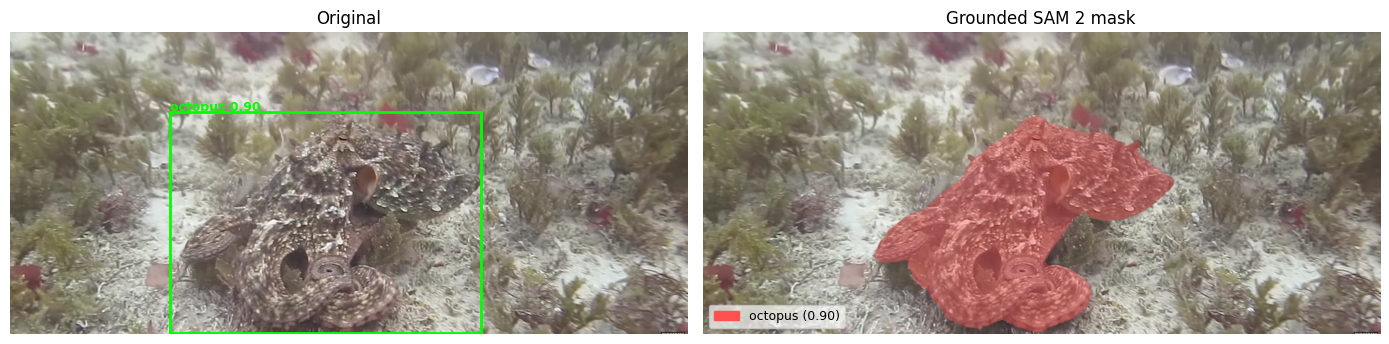

In [24]:
IMAGE_DIR = Path("octo-images")
TEXT_PROMPT = "octopus"
BOX_THRESHOLD = 0.3
TEXT_THRESHOLD = 0.25

image_paths = sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg"))
print(f"Found {len(image_paths)} images.")

sample_path = image_paths[0]
print(f"Running on: {sample_path.name}")

image_pil = Image.open(sample_path).convert("RGB")
image_np  = np.array(image_pil)

boxes, scores, phrases = detect_with_gdino(image_pil, TEXT_PROMPT, BOX_THRESHOLD, TEXT_THRESHOLD)
print(f"Detections: {len(boxes)} — phrases: {phrases}, scores: {scores.round(2)}")

masks, mask_scores = segment_with_sam2(image_np, boxes)

# Build matplotlib legend handles
legend_handles = [
    patches.Patch(color=COLORS_MPL[i % len(COLORS_MPL)], label=f"{phrase} ({score:.2f})")
    for i, (phrase, score) in enumerate(zip(phrases, scores))
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(image_pil)
axes[0].set_title("Original")
for box, score, phrase in zip(boxes, scores, phrases):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="lime", facecolor="none")
    axes[0].add_patch(rect)
    axes[0].text(x1, y1-5, f"{phrase} {score:.2f}", color="lime", fontsize=9, fontweight="bold")

result = overlay_masks(image_np, masks)
axes[1].imshow(result)
axes[1].set_title("Grounded SAM 2 mask")
if legend_handles:
    axes[1].legend(handles=legend_handles, loc="lower left", framealpha=0.7, fontsize=9)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Batch over all images

In [25]:
OUTPUT_DIR = Path("segmented-output")
OUTPUT_DIR.mkdir(exist_ok=True)

for img_path in image_paths:
    image_pil = Image.open(img_path).convert("RGB")
    image_np  = np.array(image_pil)

    boxes, scores, phrases = detect_with_gdino(image_pil, TEXT_PROMPT, BOX_THRESHOLD, TEXT_THRESHOLD)
    masks, _ = segment_with_sam2(image_np, boxes)

    result_np = overlay_masks(image_np, masks) if len(masks) > 0 else image_np
    result_pil = draw_legend(Image.fromarray(result_np), phrases, scores.tolist())

    out_path = OUTPUT_DIR / img_path.name
    result_pil.save(out_path)
    status = f"{len(boxes)} detection(s)" if len(boxes) else "no detection"
    print(f"{img_path.name}: {status} -> saved to {out_path}")

print("All done.")

img-1.png: 1 detection(s) -> saved to segmented-output/img-1.png
img-10.png: 3 detection(s) -> saved to segmented-output/img-10.png
img-11.png: 3 detection(s) -> saved to segmented-output/img-11.png
img-12.png: 3 detection(s) -> saved to segmented-output/img-12.png
img-13.png: 4 detection(s) -> saved to segmented-output/img-13.png
img-14.png: 1 detection(s) -> saved to segmented-output/img-14.png
img-15.png: 1 detection(s) -> saved to segmented-output/img-15.png
img-16.png: 2 detection(s) -> saved to segmented-output/img-16.png
img-17.png: 1 detection(s) -> saved to segmented-output/img-17.png
img-18.png: 2 detection(s) -> saved to segmented-output/img-18.png
img-19.png: 1 detection(s) -> saved to segmented-output/img-19.png
img-2.png: 1 detection(s) -> saved to segmented-output/img-2.png
img-20.png: 2 detection(s) -> saved to segmented-output/img-20.png
img-21.png: 3 detection(s) -> saved to segmented-output/img-21.png
img-22.png: 1 detection(s) -> saved to segmented-output/img-22.png

## 6. Tune thresholds if detections are missed

If DINO misses the octopus (common when camouflaged), try:
- Lower `BOX_THRESHOLD` to `0.15`
- Broaden the prompt: `"octopus . cephalopod . animal"`
- Or fall back to SAM 2 automatic mask generator on missed frames

Auto-generated 23 masks


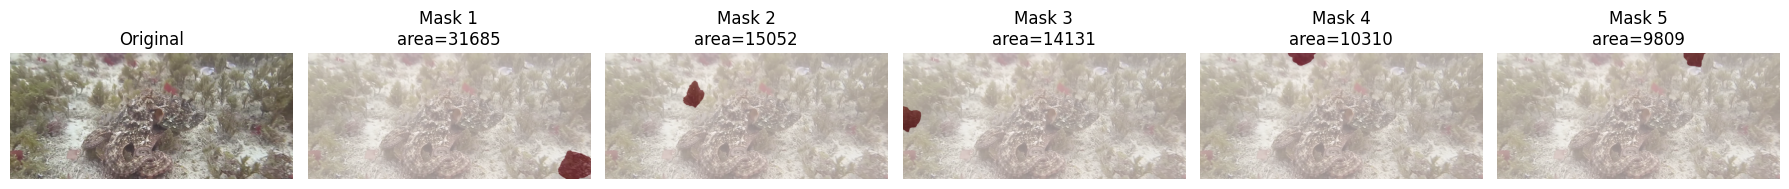

In [26]:
# Fallback: SAM2 automatic segmentation for a single image
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

auto_generator = SAM2AutomaticMaskGenerator(sam2_model, points_per_side=32, pred_iou_thresh=0.8)

fallback_path = image_paths[0]
fallback_np = np.array(Image.open(fallback_path).convert("RGB"))
all_masks = auto_generator.generate(fallback_np)

print(f"Auto-generated {len(all_masks)} masks")

# Sort by area descending and show the top 5
all_masks_sorted = sorted(all_masks, key=lambda x: x["area"], reverse=True)
top_masks = [m["segmentation"] for m in all_masks_sorted[:5]]

fig, axes = plt.subplots(1, len(top_masks)+1, figsize=(18, 4))
axes[0].imshow(fallback_np)
axes[0].set_title("Original")
for i, mask in enumerate(top_masks):
    axes[i+1].imshow(fallback_np)
    axes[i+1].imshow(mask, alpha=0.5, cmap="Reds")
    axes[i+1].set_title(f"Mask {i+1}\narea={all_masks_sorted[i]['area']}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()